In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split


In [2]:
df=pd.read_csv("../data/devis_prepared.csv")
y=df["prix_final"]
X=df.drop(columns=["prix_final"])

In [3]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape , X_test.shape)

(800, 11) (200, 11)


In [4]:
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

model_lr=LinearRegression()
model_xg=XGBRegressor()
model_cat=CatBoostRegressor()

model_lr.fit(X_train,y_train)
model_xg.fit(X_train,y_train)
model_cat.fit(X_train,y_train)

Learning rate set to 0.039525
0:	learn: 1217.9580674	total: 138ms	remaining: 2m 17s
1:	learn: 1179.1735263	total: 140ms	remaining: 1m 9s
2:	learn: 1139.0266673	total: 142ms	remaining: 47s
3:	learn: 1101.9514168	total: 144ms	remaining: 36s
4:	learn: 1065.3637553	total: 147ms	remaining: 29.2s
5:	learn: 1029.9368388	total: 148ms	remaining: 24.5s
6:	learn: 996.5535407	total: 150ms	remaining: 21.2s
7:	learn: 966.0886208	total: 152ms	remaining: 18.8s
8:	learn: 936.0049388	total: 154ms	remaining: 16.9s
9:	learn: 905.7709617	total: 156ms	remaining: 15.4s
10:	learn: 878.9190269	total: 158ms	remaining: 14.2s
11:	learn: 851.6896059	total: 160ms	remaining: 13.2s
12:	learn: 825.0416626	total: 162ms	remaining: 12.3s
13:	learn: 800.6452148	total: 164ms	remaining: 11.5s
14:	learn: 776.6982577	total: 166ms	remaining: 10.9s
15:	learn: 754.2820656	total: 167ms	remaining: 10.3s
16:	learn: 734.1741943	total: 168ms	remaining: 9.73s
17:	learn: 712.2400046	total: 170ms	remaining: 9.29s
18:	learn: 692.1815382	

CatBoostRegressor(loss_function='RMSE')

In [5]:
#comparer les models

from sklearn.metrics import mean_absolute_error,r2_score
models={
    "Regression Lineaire":model_lr,
    "XGBoost":model_xg,
    "CatBoost":model_cat
}
for name,model in models.items():
    y_pred=model.predict(X_test)
    mae=mean_absolute_error(y_test,y_pred)
    r2=r2_score(y_test,y_pred)
    print(f"{name} -> MAE: {mae} , r2: {r2}")

Regression Lineaire -> MAE: 307.28672841413214 , r2: 0.888827613168383
XGBoost -> MAE: 116.00706352539062 , r2: 0.9833654640820626
CatBoost -> MAE: 97.86001167343588 , r2: 0.9893170911616543


In [6]:
#sauvgarder le modele
import joblib
import os
os.makedirs("../models",exist_ok=True)
joblib.dump(model_cat,"../models/catboost_model.pkl")

['../models/catboost_model.pkl']

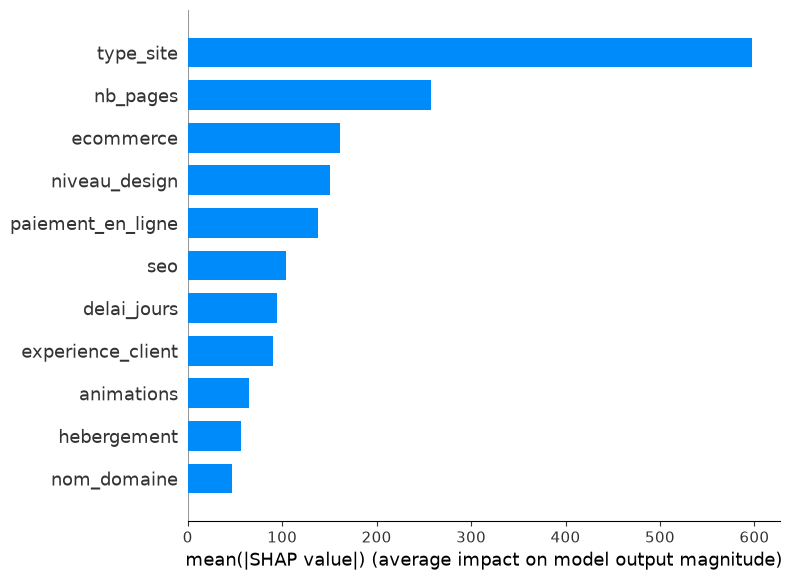

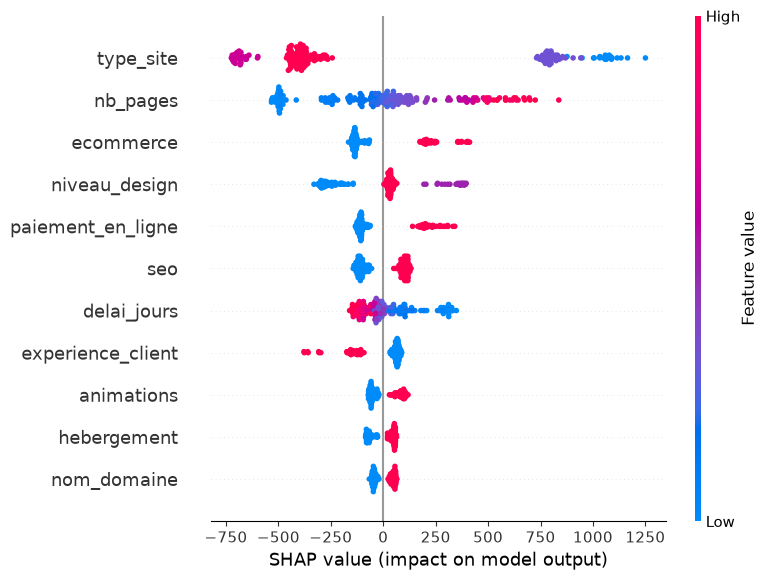

In [7]:
import shap
explainer=shap.Explainer(model_cat)
shap_values=explainer(X_test)
shap.summary_plot(shap_values,X_test,plot_type="bar")
shap.summary_plot(shap_values,X_test)